# 01 · Análisis exploratorio

**Objetivo:** entender la estructura del dataset, definir el split temporal
y explorar las variables sobre el conjunto de entrenamiento.

## 1. Librerías y configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yaml

pd.set_option("display.float_format", "{:,.2f}".format)

with open("../config.yaml") as configuracion:
    config = yaml.safe_load(configuracion)

## 2. Carga y validación de la base

In [2]:
# Lectura de la información
df = pd.read_csv("../" + config["data_path"])
df.shape

(150000, 19)

### 2.1 Estructura y tipos

In [ ]:
# Tipo de datos
df.dtypes

a           int64
b         float64
c         float64
d         float64
e         float64
f         float64
g             str
h           int64
j             str
k         float64
l         float64
m         float64
n           int64
o             str
p             str
fecha         str
monto     float64
score       int64
fraude      int64
dtype: object

In [4]:
df.head()

,a,b,c,d,e,f,g,h,j,k,l,m,n,o,p,fecha,monto,score,fraude
0,4,0.68,"50,084.12",50.00,0.00,20.00,AR,1,cat_d26ab52,0.37,"2,479.00",952.00,1,NaN,Y,2020-03-20 09:28:19,57.63,100,0
1,4,0.67,"66,005.49",0.00,0.00,2.00,AR,1,cat_ea962fb,0.61,"2,603.00",105.00,1,Y,Y,2020-03-09 13:58:28,40.19,25,0
2,4,0.47,"7,059.05",4.00,0.46,92.00,BR,25,cat_4c2544e,0.65,"2,153.00",249.00,1,Y,Y,2020-04-08 12:25:55,5.77,23,0
3,4,0.73,"10,043.10",24.00,0.05,43.00,BR,43,cat_1b59ee3,0.69,"4,845.00",141.00,1,N,Y,2020-03-14 11:46:13,40.89,23,0
4,4,0.78,"16,584.42",2.00,0.15,54.00,BR,0,cat_9bacaa5,0.20,"2,856.00",18.00,1,Y,N,2020-03-23 14:17:13,18.98,71,0


**Observaciones:**
- La columna `fecha` viene como texto
- Varias columnas que parecen enteras (`d`, `f`, `l`, `m`) aparecen como decimales,
  posiblemente por valores nulos. Se revisa en el control de calidad.
- Las filas no están ordenadas por fecha.

### 2.2 Conversión de fecha

In [5]:
# Conversión de fecha: texto -> datetime
df["fecha"] = pd.to_datetime(df["fecha"], format="%Y-%m-%d %H:%M:%S")

### 2.3 Validación de la variable objetivo

In [6]:
df["fraude"].value_counts(dropna=False)

fraude
0    142500
1      7500
Name: count, dtype: int64

In [ ]:
# Porcentaje de 1 y 0
df["fraude"].value_counts(normalize=True)

fraude
0   0.95
1   0.05
Name: proportion, dtype: float64

La variable objetivo es binaria (0: buenas, 1: fraude) y no tiene nulos. 
- Buenas: 95%
- Fraude: 5%

## 3. Inspección temporal y split

In [ ]:
# Máximo y m'inimo de fecha
df["fecha"].min(), df["fecha"].max()

(Timestamp('2020-03-08 00:02:15'), Timestamp('2020-04-21 23:59:56'))

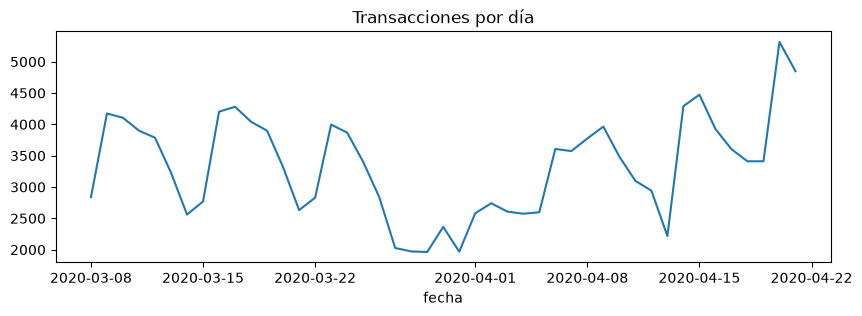

In [ ]:
# Cantidad de trx por día
diario = df.groupby(df["fecha"].dt.date)["fraude"].agg(["count", "mean"])
diario["count"].plot(figsize=(10, 3), title="Transacciones por día")
plt.show()

In [ ]:
# Días totales en la base
len(diario)

45

In [ ]:
# Distribución semanal de las trx en cantidad y tasa de fraude
semanal = df.groupby(df["fecha"].dt.to_period("W"))["fraude"].agg(["count", "mean"])
semanal

,count,mean
fecha,,
2020-03-02/2020-03-08,2838,0.04
2020-03-09/2020-03-15,24523,0.05
2020-03-16/2020-03-22,25199,0.05
2020-03-23/2020-03-29,20069,0.06
2020-03-30/2020-04-05,17434,0.06
2020-04-06/2020-04-12,24443,0.05
2020-04-13/2020-04-19,25332,0.04
2020-04-20/2020-04-26,10162,0.05


### 3.1 Definición de la separación temporal

In [ ]:
# La definición del split por fecha se guarda en configuracion (config.yaml)
corte_validacion = pd.Timestamp(config["split"]["validacion_desde"])
corte_test = pd.Timestamp(config["split"]["test_desde"])

conjunto = np.where(
    df["fecha"] < corte_validacion, "entrenamiento",
    np.where(df["fecha"] < corte_test, "validacion", "test"),
)

resumen = (
    df.groupby(conjunto)["fraude"]
    .agg(["count", "sum", "mean"])
    .reindex(["entrenamiento", "validacion", "test"])
)
resumen["proporcion"] = resumen["count"] / len(df)
resumen

,count,sum,mean,proporcion
entrenamiento,90063,4607,0.05,0.60
validacion,24443,1322,0.05,0.16
test,35494,1571,0.04,0.24


In [ ]:
# varificar que el split no haya perdido datos
print(resumen["count"].sum())

150000


### Conclusiones de la sección 3

- Los datos cubren 45 días, del 8 de marzo al 21 de abril de 2020, sin días faltantes.
- Las compras siguen un ciclo semanal: suben a inicio de semana y bajan el fin de semana.
  Por eso el análisis se hace por semana y no por día.
- Entre el 27 de marzo y el 5 de abril bajan las compras, el ciclo semanal casi desaparece
  y la tasa de fraude sube (de aprox 4,5% a aprox. 5,6%).
  Una posible explicación son las cuarentenas por COVID, aunque los datos no permiten confirmarlo.
- Como la tasa de fraude cambia con el tiempo, separar los datos al azar haría que entrenamiento
  y prueba compartan los mismos días y patrones de fraude. El modelo parecería mejor de lo que es
  (fuga de información temporal). Por eso se usa una separación temporal: entrenar con el pasado
  y evaluar con un periodo posterior.
- Nota: la tabla semanal incluye todo el periodo. Es lo mínimo necesario para definir
  la separación; el análisis de variables se hace solo con los datos de entrenamiento.
- Separación elegida: entrenamiento del 8 de marzo al 5 de abril (60%), validación del 6 al 12
  de abril (16%) y prueba del 13 al 21 de abril (24%). Los cortes coinciden con el inicio de semana
  (lunes) y cada conjunto tiene suficientes fraudes para evaluar.
  La prueba tiene la tasa de fraude más baja (4,4%), lo que la hace un escenario realista:
  el modelo se evalúa en un periodo distinto al que aprendió.

## 4. Control de calidad

### 4.1 Registros duplicados

In [14]:
df.duplicated().sum()

np.int64(0)

No hay registros duplicados exactos (filas idénticas en todas sus columnas).
Al no existir un identificador de transacción, no es posible verificar duplicados
de otro tipo, como una misma transacción registrada con diferencias menores.

### 4.2 Valores nulos

In [ ]:
# Cantidad de nulos por variable
nulos = pd.DataFrame({
    "cantidad": df.isna().sum(),
    "porcentaje": (df.isna().mean() * 100).round(2),
})
nulos[nulos["cantidad"] > 0].sort_values("porcentaje", ascending=False)

,cantidad,porcentaje
o,108857,72.57
b,12984,8.66
c,12984,8.66
d,365,0.24
m,365,0.24
g,194,0.13
f,11,0.01
l,11,0.01


In [ ]:
# Análisis de parejas de variables con la misma cantidad de nulos
parejas = [("b", "c"), ("d", "m"), ("f", "l")]

for col1, col2 in parejas:
    coinciden = (df[col1].isna() == df[col2].isna()).all()
    print(f"{col1} y {col2}: nulos en las mismas filas = {coinciden}")

b y c: nulos en las mismas filas = True
d y m: nulos en las mismas filas = True
f y l: nulos en las mismas filas = True


**Observaciones:**
- `o` tiene 72,6% de nulos: muchos para ser errores puntuales; probablemente el vacío
  tiene un significado. Se analiza en el EDA.
- `b` y `c` (8,7%), `d` y `m` (0,24%) y `f` y `l` (0,01%) tienen nulos exactamente en las
  mismas filas. Probablemente cada pareja proviene de la misma fuente de datos.
- Los nulos de `d`, `f`, `l` y `m` explican por qué pandas las leyó como decimales.
- `g` tiene 0,13% de nulos.
- Aquí solo se miden los nulos; cómo tratarlos se decide con el conjunto de entrenamiento.

### 4.3 Variables numéricas

In [17]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
a,"150,000.00",3.71,1.00,4.00,4.00,4.00,4.00,0.75
b,"137,016.00",0.73,0.00,0.68,0.76,0.81,1.00,0.13
c,"137,016.00","260,445.11",0.16,"9,679.91","43,711.65","145,443.63","13,878,743.71","846,436.14"
d,"149,635.00",21.68,0.00,2.00,14.00,50.00,50.00,20.06
e,"150,000.00",0.22,0.00,0.00,0.10,0.28,833.33,2.43
f,"149,989.00",51.17,-5.00,1.00,8.00,33.00,"145,274.00",709.47
h,"150,000.00",14.19,0.00,3.00,9.00,21.00,58.00,14.16
k,"150,000.00",0.50,0.00,0.25,0.50,0.75,1.00,0.29
l,"149,989.00","2,305.41",0.00,910.00,"1,937.00","3,445.00","7,544.00","1,712.38"
m,"149,635.00",299.97,0.00,42.00,193.00,459.00,"2,225.00",321.08


In [18]:
print("Valores negativos en f:", (df["f"] < 0).sum())
print("Valores iguales a 50 en d:", (df["d"] == 50).sum())
print("Valores mayores a 1 en e:", (df["e"] > 1).sum())
print("Valores distintos en a:", df["a"].nunique(), "|", df["a"].value_counts().to_dict())
print("Valores distintos en n:", df["n"].nunique(), "|", df["n"].value_counts().to_dict())
print("Valores distintos en k:", df["k"].nunique())

Valores negativos en f: 1277
Valores iguales a 50 en d: 38597
Valores mayores a 1 en e: 3643
Valores distintos en a: 4 | {4: 128579, 2: 14378, 1: 4195, 3: 2848}
Valores distintos en n: 2 | {1: 135353, 0: 14647}
Valores distintos en k: 150000


In [ ]:
# Porcentajes
print("f negativos:", round((df["f"] < 0).mean() * 100, 2), "%")
print("d igual a 50:", round((df["d"] == 50).mean() * 100, 1), "%")
print("e entre 0 y 1:", round((df["e"] <= 1).mean() * 100, 1), "%")
print("a:", (df["a"].value_counts(normalize=True) * 100).round(1).to_dict())
print("n:", (df["n"].value_counts(normalize=True) * 100).round(1).to_dict())

d igual a 50: 25.7 %
e entre 0 y 1: 97.6 %
f negativos: 0.85 %
a: {4: 85.7, 2: 9.6, 1: 2.8, 3: 1.9}
n: {1: 90.2, 0: 9.8}


In [ ]:
#Comportamiento de los negativos de f
df.loc[df["f"] < 0, "f"].value_counts()

f
-1.00    877
-2.00    335
-3.00     58
-4.00      6
-5.00      1
Name: count, dtype: int64

In [ ]:
#percentiles altos de c, e y f
df[["c", "e", "f"]].quantile([0.75, 0.90, 0.95, 0.99, 0.999])

,c,e,f
0.75,"145,443.63",0.28,33.00
0.90,"454,000.63",0.50,92.00
0.95,"1,031,954.91",0.71,162.00
0.99,"4,948,124.06",1.42,483.00
1.00,"10,117,356.49",5.00,"3,264.28"


In [21]:
for col in ["e", "f"]:
    print(f"{col}: 10 valores más altos")
    print(df[col].nlargest(10).tolist(), "\n")

e: 10 valores más altos
[833.3333333333333, 285.0857142857143, 165.66666666666666, 82.33333333333333, 82.16666666666666, 65.91, 56.86695278969957, 56.5, 51.0, 49.266666666666666] 

f: 10 valores más altos
[145274.0, 135050.0, 75535.0, 58981.0, 38350.0, 38077.0, 37941.0, 33516.0, 33275.0, 32614.0] 



In [35]:
#verificar si k aumenta con la fecha
df["k"].corr(df["fecha"].astype("int64"), method="spearman")

np.float64(0.0016006520997609449)

**Observaciones:**
- `monto` va de 0,02 a 3.696, sin negativos ni ceros. Hay muchas compras pequeñas y pocas
  muy grandes (mediana 20,6; promedio 43,5).
- `score` va de 0 a 100.
- Para `c`, `e` y `f` se revisaron los percentiles altos y los 10 valores más altos:
  - `c` crece de forma continua: sus valores grandes son parte normal de la distribución.
  - `e` y `f` son parejas hasta el percentil 99,9 y luego tienen una cola de valores muy altos
    que bajan de forma gradual. No son errores aislados, así que se conservan.
- `d` tiene el 25,7% de sus valores en 50 (su máximo). Parece tener un tope: 50.
- `f` tiene 1.277 valores negativos (de -1 a -5), con frecuencias que bajan de forma gradual.
  No parece un código especial ni un error, así que se conservan.
- `a` (4 valores) y `n` (2 valores) funcionan como categorías codificadas con números.
- `k` tiene un valor distinto por fila y se distribuye de forma casi uniforme entre 0 y 1.
  Podría ser un identificador de transacción. Su correlación con la fecha es prácticamente
  cero (0,002), así que no sigue el orden temporal. En el análisis exploratorio se verificará si tiene relación
  con el fraude.

### 4.4 Variables categóricas

In [23]:
for col in ["g", "j", "o", "p"]:
    print(f"{col}: {df[col].nunique()} valores distintos")
    print(df[col].value_counts(dropna=False).head(5).to_dict(), "\n")

g: 51 valores distintos
{'BR': 111628, 'AR': 31964, 'UY': 2967, 'US': 2273, 'SE': 358} 

j: 8324 valores distintos
{'cat_43b9c10': 2331, 'cat_d69bed9': 1799, 'cat_604df77': 1784, 'cat_6c4cfdc': 1449, 'cat_4249bd8': 1191} 

o: 2 valores distintos
{nan: 108857, 'Y': 24091, 'N': 17052} 

p: 2 valores distintos
{'Y': 83129, 'N': 66871} 



In [24]:
# Formato: todos los códigos de g con dos letras mayúsculas y todos los de j con el prefijo cat_
print("g con formato distinto a dos mayúsculas:", (~df["g"].dropna().str.fullmatch(r"[A-Z]{2}")).sum())
print("j sin prefijo cat_:", (~df["j"].str.startswith("cat_")).sum())

# Cola larga: categorías con menos de 10 transacciones
for col in ["g", "j"]:
    conteo = df[col].value_counts()
    print(f"{col}: {(conteo < 10).sum()} de {len(conteo)} categorías tienen menos de 10 transacciones")

g con formato distinto a dos mayúsculas: 0
j sin prefijo cat_: 0
g: 38 de 51 categorías tienen menos de 10 transacciones
j: 5944 de 8324 categorías tienen menos de 10 transacciones


In [25]:
# Porcentajes que respaldan las conclusiones de la sección 4.4
print("g:", (df["g"].value_counts(normalize=True) * 100).round(1).head(5).to_dict())
print("j, categoría más frecuente:", round(df["j"].value_counts(normalize=True).iloc[0] * 100, 1), "%")
print("o:", (df["o"].value_counts(normalize=True, dropna=False) * 100).round(1).to_dict())
print("p:", (df["p"].value_counts(normalize=True) * 100).round(1).to_dict())

conteo_j = df["j"].value_counts()
print("j, categorías con menos de 10 transacciones:", round((conteo_j < 10).mean() * 100, 1), "%")

g: {'BR': 74.5, 'AR': 21.3, 'UY': 2.0, 'US': 1.5, 'SE': 0.2}
j, categoría más frecuente: 1.6 %
o: {nan: 72.6, 'Y': 16.1, 'N': 11.4}
p: {'Y': 55.4, 'N': 44.6}
j, categorías con menos de 10 transacciones: 71.4 %


**Observaciones:**
- El formato es consistente: todos los valores de `g` tienen dos letras mayúsculas
  y todos los de `j` empiezan con `cat_`.
- `g` parece indicar país: 51 valores, con Brasil (74,5%) y Argentina (21,3%) concentrando
  casi todo. 38 países tienen menos de 10 transacciones.
- `j` tiene 8.324 categorías y el 71% tiene menos de 10 transacciones. Habrá que agrupar
  las categorías poco frecuentes y prever categorías nuevas en producción.
- `o` tiene en la práctica tres estados: sí, no y vacío (72,6%).
- `p` es binaria y no tiene nulos.

### Conclusiones de la sección 4

- La base no tiene duplicados exactos y los formatos son consistentes.
- Los nulos se concentran en `o` (72,6%) y en parejas de variables que fallan juntas,
  probablemente porque vienen de la misma fuente.
- Varias variables tienen valores extremos (`c`, `e`, `f`) y `d` tiene un tope en 50.
- `a` y `n` son categorías codificadas con números, y `k` se comporta como un número aleatorio.
- `j` tiene una cola muy larga de categorías poco frecuentes.
- Ninguno de estos hallazgos requiere eliminar datos. El tratamiento de cada uno se decide
  en el análisis exploratorio, usando solo el conjunto de entrenamiento.